<a href="https://colab.research.google.com/github/JyothikaCN/xyz/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchvision tqdm matplotlib pandas pillow

In [3]:
# Import Libraries Cell
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm import tqdm
import glob
import re
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import glob
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image

class SareeBlouseDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        """
        Args:
            csv_path: Path to the CSV file with annotations
            img_dir: Directory with all the images
            transform: Optional transform to be applied on images
        """
        self.data = pd.read_csv(csv_path)
        # Filter out rows with empty design_type
        self.data = self.data.dropna(subset=['design_type'])
        self.img_dir = img_dir
        self.transform = transform

        # Map all image files in the directory
        self.image_files = {}
        for img_path in glob.glob(os.path.join(img_dir, '*')):
            basename = os.path.basename(img_path).split('.')[0]  # Get filename without extension
            self.image_files[basename] = img_path

        # Create vocabularies for text encoding (all text columns)
        self.text_columns = ['design_type', 'neckline', 'orientation', 'sleeve_type',
                             'embelishments', 'color', 'pattern', 'dori', 'material']
        self.vocab = self._create_vocabulary()

    def _create_vocabulary(self):
        """Create a vocabulary from all text columns"""
        all_words = []
        for col in self.text_columns:
            if col in self.data.columns:
                for text in self.data[col].dropna():
                    words = str(text).lower().split()
                    all_words.extend(words)

        # Get unique words
        unique_words = sorted(list(set(all_words)))
        # Create word to index mapping
        word2idx = {word: idx+1 for idx, word in enumerate(unique_words)}
        # Add padding token
        word2idx['<PAD>'] = 0

        return word2idx

    def encode_text(self, text, max_length=10):
        """Convert text description to numerical vector"""
        if pd.isna(text):
            return torch.zeros(max_length, dtype=torch.long)

        words = str(text).lower().split()
        encoding = [self.vocab.get(word, 0) for word in words]

        # Pad or truncate to fixed length
        if len(encoding) > max_length:
            encoding = encoding[:max_length]
        else:
            encoding.extend([0] * (max_length - len(encoding)))

        return torch.tensor(encoding, dtype=torch.long)

    def encode_all_attributes(self, idx):
        """Encode all text attributes for a given sample"""
        encodings = []

        for col in self.text_columns:
            if col in self.data.columns:
                text = self.data.iloc[idx][col]
                encoding = self.encode_text(text)
                encodings.append(encoding)
            else:
                # For missing columns, add zero encoding
                encodings.append(torch.zeros(10, dtype=torch.long))

        return torch.cat(encodings)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx]['image']  # image column contains identifiers like 'b1', 'b2'

        # Find the image file with matching basename
        img_path = self.image_files.get(img_id, None)
        if img_path is None:
            for ext in ['.jpg', '.jpeg', '.png']:
                possible_path = os.path.join(self.img_dir, f"{img_id}{ext}")
                if os.path.exists(possible_path):
                    img_path = possible_path
                    break
            else:
                raise FileNotFoundError(f"No image file found for {img_id}")

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a placeholder image and encoding
            image = Image.new('RGB', (64, 64), color='gray')

        if self.transform:
            image = self.transform(image)

        # Encode all text attributes
        text_encoding = self.encode_all_attributes(idx)

        # Get the design type for reference
        design_type = self.data.iloc[idx]['design_type']

        return image, text_encoding, design_type


In [16]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, text_length=90):
        super(TextEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # The text length should match what's expected in the discriminator
        self.fc1 = nn.Linear(embedding_dim * text_length, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        embedded = self.embedding(x)
        # Flatten the embeddings to match the expected text dimension
        embedded = embedded.view(embedded.shape[0], -1)
        hidden = self.relu(self.fc1(embedded))
        output = self.fc2(hidden)
        return output



In [6]:
class Generator(nn.Module):
    def __init__(self, z_dim, text_dim, channels):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.text_dim = text_dim

        self.init_size = 8  # Initial size before upsampling
        self.l1 = nn.Sequential(nn.Linear(z_dim + text_dim, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, text_embedding):
        gen_input = torch.cat([z, text_embedding], dim=1)
        out = self.l1(gen_input)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img


In [41]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_channels=3, img_size=64, text_embedding_dim=128):
        super(Discriminator, self).__init__()

        # Define CNN for image feature extraction
        self.cnn = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Compute CNN output size dynamically
        with torch.no_grad():
          dummy_img = torch.randn(1, 3, 64, 64)  # Match training input size
          dummy_output = self.cnn(dummy_img)
          print(f"Dummy CNN output shape: {dummy_output.shape}")  # Debug output shape
          self.cnn_output_size = dummy_output.view(1, -1).shape[1]

        self.adv_layer_input_size = self.cnn_output_size + text_embedding_dim
        print(f"Computed adv_layer_input_size: {self.adv_layer_input_size}")  # Debugging

        # Define fully connected adversarial layer
        self.adv_layer = nn.Sequential(
            nn.Linear(self.adv_layer_input_size, 1),
            nn.Sigmoid()
        )
    def forward(self, img, text_embedding):
        img_features = self.cnn(img)

        print(f"Raw img_features shape: {img_features.shape}")  # Debug CNN output

        # Flattening dynamically to avoid shape mismatch
        img_features = img_features.view(img_features.size(0), -1)

        text_embedding = text_embedding.view(text_embedding.size(0), -1)
        concat = torch.cat((img_features, text_embedding), dim=1)

        print(f"Flattened img_features shape: {img_features.shape}")  # Debug CNN output
        print(f"text_embedding shape: {text_embedding.shape}")  # Debug embedding
        print(f"Concatenated size: {concat.shape[1]}")
        print(f"Expected input size: {self.adv_layer_input_size}")

        if concat.shape[1] != self.adv_layer_input_size:
            raise ValueError(f"Input size mismatch for adv_layer: Got {concat.shape[1]}, expected {self.adv_layer_input_size}")

        validity = self.adv_layer(concat)
        return validity


In [28]:
print(f"img_features shape: {img_features.shape}")  # Debug CNN output size
print(f"text_embedding shape: {text_embedding.shape}")  # Debug text embedding size


NameError: name 'img_features' is not defined

In [47]:
# import os
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# from torch.utils.data import DataLoader
# from torchvision import transforms
# from tqdm import tqdm
# from dataset import SareeBlouseDataset
# from models import Generator, Discriminator, TextEncoder

def train_cgan(csv_path, img_dir, num_epochs=50, batch_size=16, save_dir='models'):
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Hyperparameters
    lr = 0.0002
    b1 = 0.5
    b2 = 0.999
    latent_dim = 100
    text_dim = 128  # Increased text dimension for multiple attributes
    img_size = 64
    channels = 3

    # Data transformations
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    # Load dataset
    dataset = SareeBlouseDataset(csv_path, img_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

    # Initialize models
    vocab_size = len(dataset.vocab) + 1  # +1 for unknown tokens
    text_encoder = TextEncoder(vocab_size, embedding_dim=32, hidden_dim=256, output_dim=text_dim,
                               text_length=90).to(device)  # 9 attributes * 10 words each
    generator = Generator(latent_dim, text_dim, channels).to(device)
    discriminator = Discriminator(channels, text_dim).to(device)

    # Loss function
    adversarial_loss = nn.BCELoss()

    # Optimizers
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

    # Track losses
    g_losses = []
    d_losses = []

    # Training loop
    for epoch in range(num_epochs):
        total_d_loss = 0
        total_g_loss = 0

        for i, (real_imgs, text_data, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
            try:
                real_imgs = real_imgs.to(device)
                text_data = text_data.to(device)

                # Get text embeddings
                text_embeddings = text_encoder(text_data)

                # Labels for real and fake images
                valid = torch.ones(real_imgs.size(0), 1, device=device)
                fake = torch.zeros(real_imgs.size(0), 1, device=device)

                # -----------------
                #  Train Generator
                # -----------------
                optimizer_G.zero_grad()

                # Sample noise and generate images
                z = torch.randn(real_imgs.size(0), latent_dim, device=device)
                gen_imgs = generator(z, text_embeddings)

                # Generator loss
                validity = discriminator(gen_imgs, text_embeddings)
                g_loss = adversarial_loss(validity, valid)

                g_loss.backward(retain_graph=True)  # No retain_graph=True (not needed anymore)
                optimizer_G.step()

                # ---------------------
                #  Train Discriminator
                # ---------------------
                optimizer_D.zero_grad()

                # Discriminator loss on real and fake images
                real_validity = discriminator(real_imgs, text_embeddings)
                fake_validity = discriminator(gen_imgs.detach(), text_embeddings)  # DETACHED to prevent extra graph tracking

                real_loss = adversarial_loss(real_validity, valid)
                fake_loss = adversarial_loss(fake_validity, fake)
                d_loss = (real_loss + fake_loss) / 2

                d_loss.backward()
                optimizer_D.step()

                total_d_loss += d_loss.item()
                total_g_loss += g_loss.item()

                # Print progress every 10 batches
                if i % 10 == 0:
                    print(
                        f"[Epoch {epoch+1}/{num_epochs}] [Batch {i}/{len(dataloader)}] "
                        f"[D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]"
                    )

            except RuntimeError as e:
                if "CUDA out of memory" in str(e):
                    print("⚠️ CUDA Out of Memory! Trying to continue training...")
                    torch.cuda.empty_cache()
                else:
                    raise e

        # Save models periodically
        if (epoch + 1) % 10 == 0 or epoch == num_epochs - 1:
            torch.save(generator.state_dict(), f"{save_dir}/generator_epoch_{epoch+1}.pth")
            torch.save(discriminator.state_dict(), f"{save_dir}/discriminator_epoch_{epoch+1}.pth")
            torch.save(text_encoder.state_dict(), f"{save_dir}/text_encoder_epoch_{epoch+1}.pth")

        # Track average losses
        avg_d_loss = total_d_loss / len(dataloader)
        avg_g_loss = total_g_loss / len(dataloader)
        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        print(f"Epoch {epoch+1}/{num_epochs} - Avg D loss: {avg_d_loss:.4f}, Avg G loss: {avg_g_loss:.4f}")

    # Save final models
    torch.save(generator.state_dict(), f"{save_dir}/generator_final.pth")
    torch.save(discriminator.state_dict(), f"{save_dir}/discriminator_final.pth")
    torch.save(text_encoder.state_dict(), f"{save_dir}/text_encoder_final.pth")

    # Save model metadata
    model_info = {
        'vocab_size': vocab_size,
        'vocab': dataset.vocab,
        'text_columns': dataset.text_columns
    }
    torch.save(model_info, f"{save_dir}/model_info.pth")

    return generator, discriminator, text_encoder, dataset


In [9]:
def encode_prompt(prompt, dataset, device):
    """Encode a text prompt dictionary into a tensor format the model expects"""
    encodings = []

    for col in dataset.text_columns:
        if col in prompt:
            text = prompt[col]
            encoding = dataset.encode_text(text)
        else:
            # For missing attributes, use zero encoding
            encoding = torch.zeros(10, dtype=torch.long)
        encodings.append(encoding)

    # Concatenate all encodings
    return torch.cat(encodings).unsqueeze(0).to(device)

In [10]:
def generate_samples(generator, text_encoder, dataset, prompt_list, device, latent_dim=100, text_dim=128):
    """Generate images from a list of prompt dictionaries"""
    generator.eval()
    text_encoder.eval()

    generated_images = []

    with torch.no_grad():
        for prompt in prompt_list:
            # Encode the prompt
            text_data = encode_prompt(prompt, dataset, device)
            text_embedding = text_encoder(text_data)

            # Generate random noise
            z = torch.randn(1, latent_dim, device=device)

            # Generate image
            gen_img = generator(z, text_embedding)

            # Convert to displayable format
            img = gen_img[0].detach().cpu().numpy().transpose(1, 2, 0)
            img = (img * 0.5 + 0.5).clip(0, 1)  # Denormalize

            generated_images.append(img)

    return generated_images

In [11]:
def generate_blouse_design(prompt, generator, text_encoder, dataset, device, latent_dim=100):
    """Generate a single blouse design from a prompt dictionary and display it"""
    generator.eval()
    text_encoder.eval()

    with torch.no_grad():
        # Encode the prompt
        text_data = encode_prompt(prompt, dataset, device)
        text_embedding = text_encoder(text_data)

        # Generate random noise
        z = torch.randn(1, latent_dim, device=device)

        # Generate image
        gen_img = generator(z, text_embedding)

        # Convert to displayable format
        img = gen_img[0].detach().cpu().numpy().transpose(1, 2, 0)
        img = (img * 0.5 + 0.5).clip(0, 1)  # Denormalize

        # Create a title from the prompt
        title_parts = []
        for key in ['color', 'design_type', 'neckline', 'sleeve_type', 'pattern']:
            if key in prompt and prompt[key]:
                title_parts.append(str(prompt[key]))
        title = " ".join(title_parts)

        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
        plt.show()

        return img, gen_img[0]  # Return both image formats


In [12]:
def load_models(model_dir, device):
    """Load trained models and metadata"""
    model_info = torch.load(f"{model_dir}/model_info.pth")
    vocab_size = model_info['vocab_size']

    # Initialize models with the correct parameters
    text_encoder = TextEncoder(vocab_size, embedding_dim=32, hidden_dim=256, output_dim=128,
                              text_length=90).to(device)
    generator = Generator(100, 128, 3).to(device)

    # Load saved weights
    text_encoder.load_state_dict(torch.load(f"{model_dir}/text_encoder_final.pth"))
    generator.load_state_dict(torch.load(f"{model_dir}/generator_final.pth"))

    return generator, text_encoder, model_info

In [13]:
def generate_variations(prompt, generator, text_encoder, dataset, device, num_variations=4, latent_dim=100):
    """Generate multiple variations of a design from the same prompt"""
    generator.eval()
    text_encoder.eval()

    with torch.no_grad():
        # Encode the prompt
        text_data = encode_prompt(prompt, dataset, device)
        text_embedding = text_encoder(text_data)

        # Generate multiple images with different noise vectors
        images = []
        for _ in range(num_variations):
            # Generate random noise
            z = torch.randn(1, latent_dim, device=device)

            # Generate image
            gen_img = generator(z, text_embedding)

            # Convert to displayable format
            img = gen_img[0].detach().cpu().numpy().transpose(1, 2, 0)
            img = (img * 0.5 + 0.5).clip(0, 1)  # Denormalize
            images.append(img)

        # Display the variations
        fig, axs = plt.subplots(1, num_variations, figsize=(16, 4))
        for i, img in enumerate(images):
            axs[i].imshow(img)
            axs[i].set_title(f"Variation {i+1}")
            axs[i].axis('off')
        plt.tight_layout()
        plt.show()

        return images

Using device: cuda
Dummy CNN output shape: torch.Size([1, 512, 4, 4])
Computed adv_layer_input_size: 8320


Epoch 1/50:   1%|          | 1/186 [00:00<00:57,  3.20it/s]

Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
[Epoch 1/50] [Batch 0/186] [D loss: 0.6530] [G loss: 0.7038]
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 

Epoch 1/50:   2%|▏         | 3/186 [00:00<00:26,  6.80it/s]

Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw i

...

Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
[Epoch 50/50] [Batch 180/186] [D loss: 0.0264] [G loss: 5.5627]
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([1

Epoch 50/50:  99%|█████████▉| 185/186 [00:23<00:00,  9.72it/s]

Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw img_features shape: torch.Size([16, 512, 4, 4])
Flattened img_features shape: torch.Size([16, 8192])
text_embedding shape: torch.Size([16, 128])
Concatenated size: 8320
Expected input size: 8320
Raw i

Epoch 50/50: 100%|██████████| 186/186 [00:23<00:00,  7.99it/s]


Epoch 50/50 - Avg D loss: 0.0459, Avg G loss: 5.2771


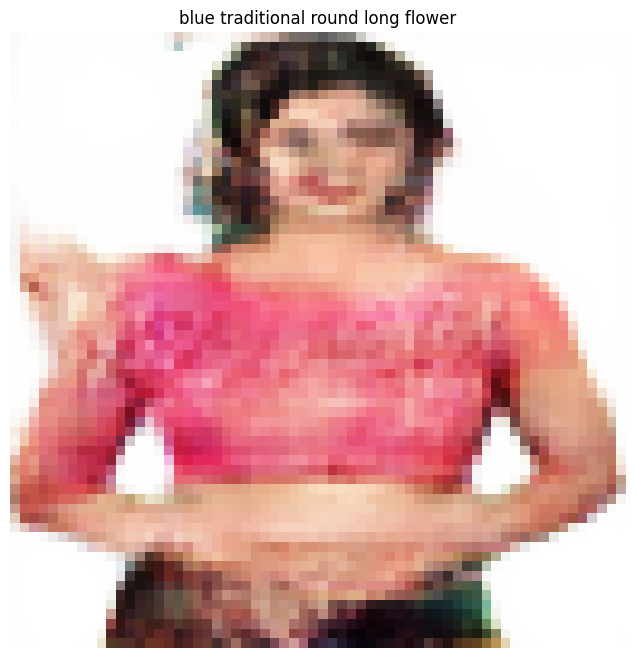

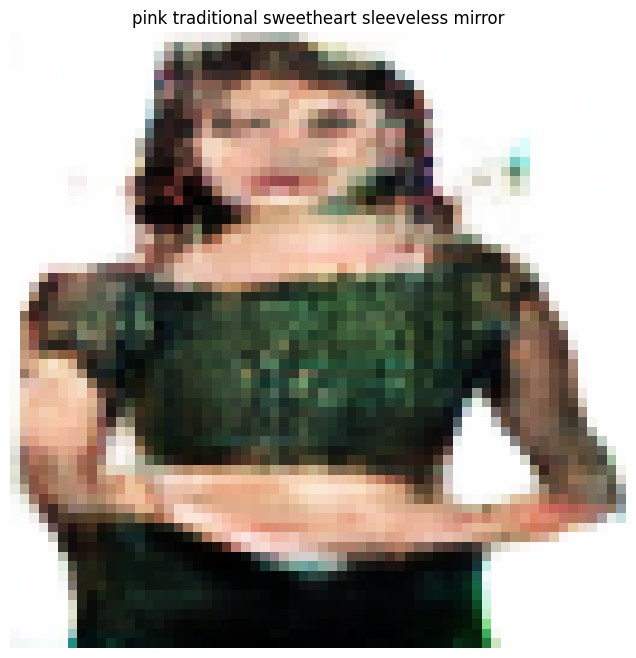

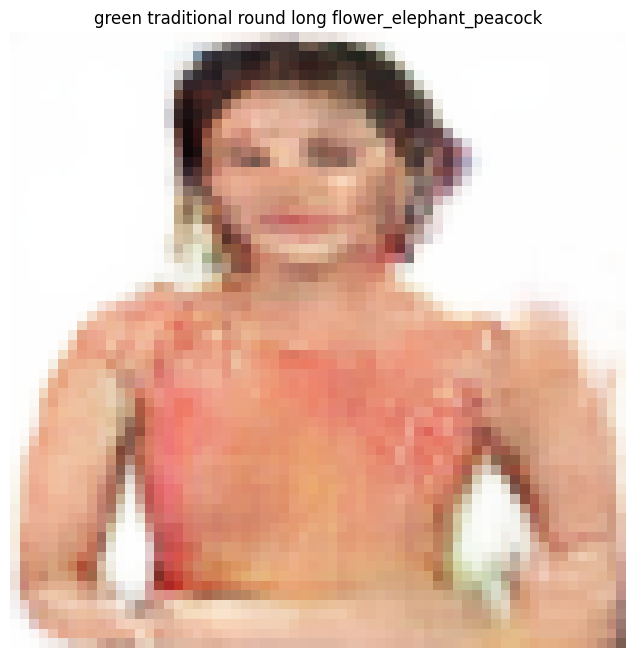

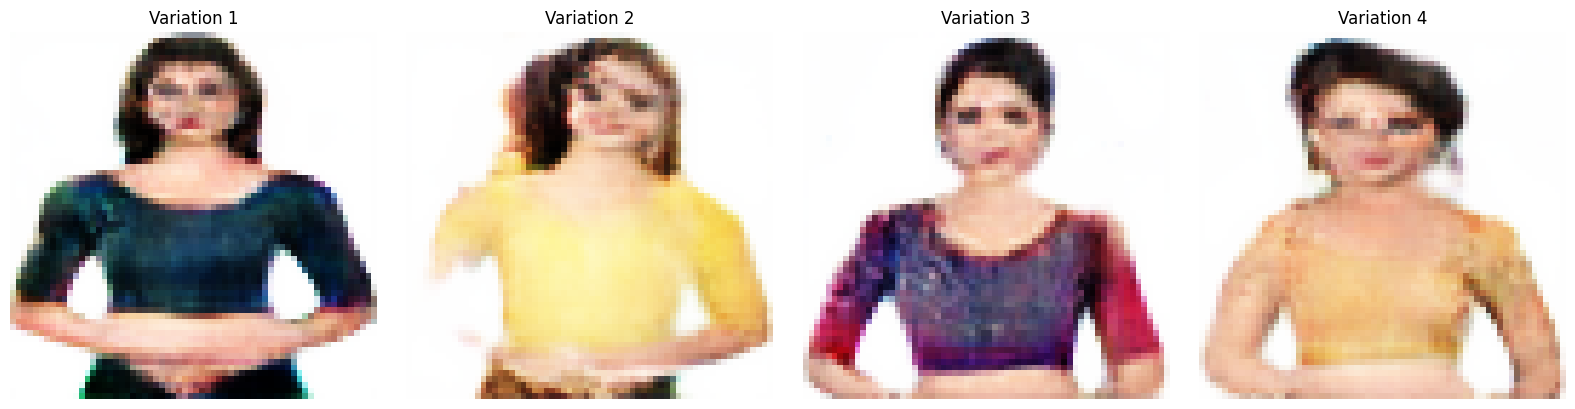

In [48]:
def main():
    # Set paths
    csv_path = '/content/drive/MyDrive/Colab Notebooks/final year project 2024-25/blouse_labels - Sheet1.csv'  # Update with your actual path
    img_dir = '/content/drive/MyDrive/Colab Notebooks/final year project 2024-25/dataset'  # Update with your actual path
    save_dir = '/content/drive/MyDrive/Colab Notebooks/final year project 2024-25'

    # Train the models
    generator, discriminator, text_encoder, dataset = train_cgan(
        csv_path=csv_path,
        img_dir=img_dir,
        num_epochs=50,  # You can adjust this based on your timeline
        batch_size=16,
        save_dir=save_dir
    )

    # Test generation with some prompts
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    test_prompts = [
        {
            'design_type': 'traditional',
            'neckline': 'round',
            'orientation': 'front',
            'sleeve_type': 'long',
            'embelishments': 'embroidery',
            'color': 'blue',
            'pattern': 'flower'
        },
        {
            'design_type': 'traditional',
            'neckline': 'sweetheart',
            'orientation': 'front',
            'sleeve_type': 'sleeveless',
            'embelishments': 'mirror',
            'color': 'pink',
            'pattern': 'mirror'
        },
        {
            'design_type': 'traditional',
            'neckline': 'round',
            'orientation': 'back',
            'sleeve_type': 'long',
            'embelishments': 'embroidery',
            'color': 'green',
            'pattern': 'flower_elephant_peacock'
        }
    ]

    # Generate individual designs
    for prompt in test_prompts:
        img, _ = generate_blouse_design(prompt, generator, text_encoder, dataset, device)

    # Generate variations of a single design
    variation_prompt = {
        'design_type': 'traditional',
        'neckline': 'round',
        'orientation': 'front',
        'sleeve_type': 'long',
        'embelishments': 'embroidery',
        'color': 'blue',
        'pattern': 'flower'
    }

    generate_variations(variation_prompt, generator, text_encoder, dataset, device, num_variations=4)



if __name__ == "__main__":
    main()

<ipython-input-12-84c3a431254d>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_info = torch.load(f"{model_dir}/model_info.pth")
<ipython-input-12-84c3a431254d>:12: F

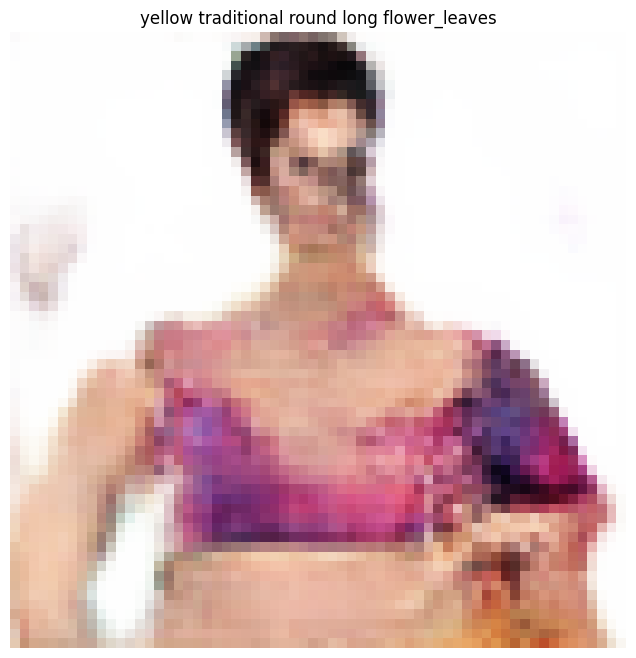

In [50]:

# Load trained models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir = '/content/drive/MyDrive/Colab Notebooks/final year project 2024-25'
generator, text_encoder, model_info = load_models(save_dir, device)

# Create a dataset instance for encoding
dataset = SareeBlouseDataset(
    '/content/drive/MyDrive/Colab Notebooks/final year project 2024-25/blouse_labels - Sheet1.csv',
    '/content/drive/MyDrive/Colab Notebooks/final year project 2024-25/dataset',
    transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
)
dataset.vocab = model_info['vocab']
dataset.text_columns = model_info['text_columns']

# Generate from a text prompt
prompt = {
    'design_type': 'traditional',
    'neckline': 'round',
    'sleeve_type': 'long',
    'embelishments': 'embroidery',
    'color': 'yellow',
    'pattern': 'flower_leaves'
}

img, _ = generate_blouse_design(prompt, generator, text_encoder, dataset, device)


In [6]:
# Define dataset paths
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/final year project 2024-25/dataset"
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/final year project 2024-25/blouse_labels - Sheet1.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)
df.head()
df = df[df['design_type'].notna()]  # Keep only rows with valid annotations

NameError: name 'img' is not defined